#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

### Data Collection

The Breast Cancer dataset was successfully loaded from the sklearn.datasets library.

It contains numerical features extracted from breast cell images and a target column representing the diagnosis (Malignant or Benign).

#### Load dataset

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data,
                  columns=data.feature_names)
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Data Understanding

In [3]:
df.shape

(569, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Data Cleaning

#### Check Missing values

In [6]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [7]:
print("Duplicated Rows:", df.duplicated().sum())

Duplicated Rows: 0


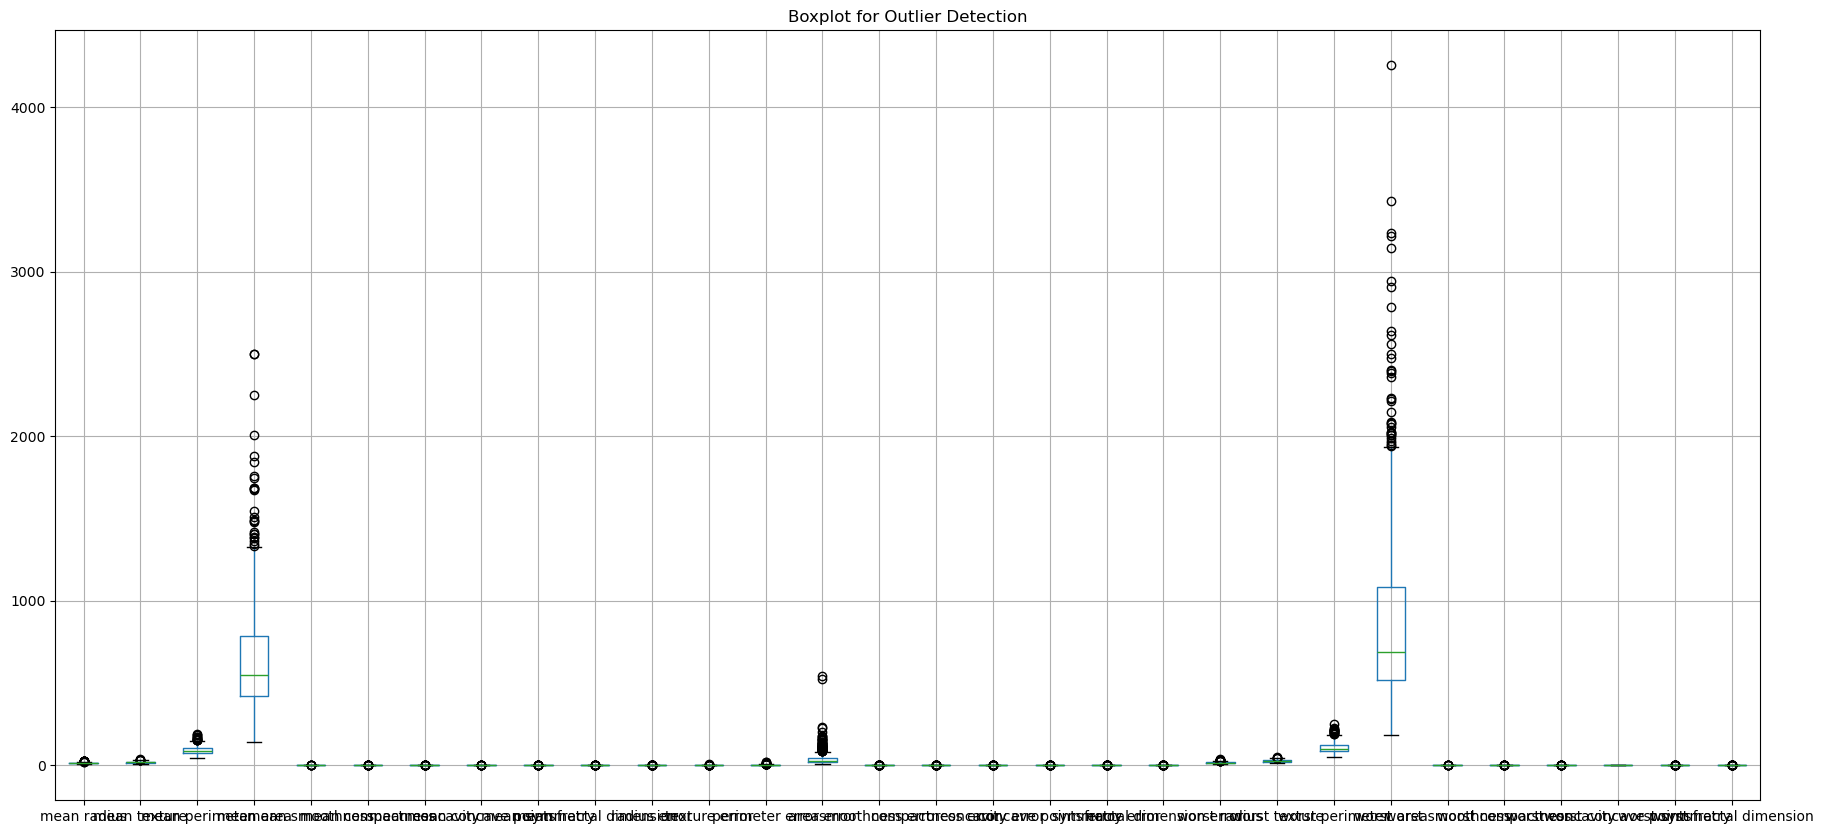

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(22,10))
df.drop("target", axis=1).boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()

In [9]:
num_cols = df.drop("target", axis=1).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1 

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)

Lower: 0.04053
Upper: 0.12301


In [10]:
outliers = df[(df[col] < lower)  | (df[col] > upper) ]

print("Outliers:\n",outliers.drop("target",axis=1))

Outliers:
      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
3         11.420         20.38           77.58      386.1          0.14250   
5         12.450         15.70           82.57      477.1          0.12780   
9         12.460         24.04           83.97      475.9          0.11860   
14        13.730         22.61           93.60      578.3          0.11310   
15        14.540         27.54           96.73      658.8          0.11390   
26        14.580         21.53           97.41      644.8          0.10540   
31        11.840         18.70           77.93      440.6          0.11090   
34        16.130         17.88          107.00      807.2          0.10400   
72        17.200         24.52          114.20      929.4          0.10710   
105       13.110         15.56           87.21      530.2          0.13980   
118       15.780         22.91          105.70      782.6          0.11550   
151        8.219         20.70           53.27      2

In [11]:
df_clean = df[(df[col] >= lower) & (df[col] <= upper)]

df_clean.shape

(545, 31)

### Data Preprocessing

#### Split Dataset

In [12]:
X = df.drop("target", axis=1)
y = df["target"]

#### Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

#### Feature Scaling

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
print(X.shape)

(569, 30)


##### Explain the preprocessing steps you performed and justify why they are necessary for this dataset?.

 1. Check Missing Values
    
* I checked the dataset for missing values using df.isnull().sum().
No missing values were found.

Missing values can affect the model's accuracy.

 2. Check Duplicate Values
  
* I checked for duplicate records using df.duplicated().sum().
No duplicate values were found.


Duplicate data can reduce the quality of the model.

3. Split Features and Target
  
* I separated the input features (X) and the target variable (y).
  
 Machine learning models need features and target values separately for training.
 
4. Split the Dataset
   
* I split the dataset into 80% training data and 20% testing data.

The training data is used to train the model, and the testing data is used to check its performance.

5. Feature Scaling
   
* I used StandardScaler to scale the feature values.

 The features have different ranges. Scaling makes them similar in size and helps models like Logistic Regression, SVM, and K-NN perform better.

### Model Building

#### Logistic Regression

In [16]:
lr = LogisticRegression(max_iter = 500)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [17]:
lr_pred = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, lr_pred))

Accuracy: 0.9824561403508771


##### Insight
Logistic Regression was trained to classify breast cancer as malignant or benign.

It is suitable for binary classification problems.

#### Decision Tree

In [18]:
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
dt_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.9122807017543859


##### Insight
Decision Tree learned decision rules from the training data.
    
It is easy to interpret but may overfit the training data.

#### Random Forest

In [20]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
rf_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.956140350877193


##### Insight
Random Forest combined multiple decision trees to improve prediction accuracy.

It generally provides better generalization than a single Decision Tree.

#### Support Vector Machine

In [22]:
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [23]:
svm_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, svm_pred))

Accuracy: 0.9824561403508771


##### Insight

SVM finds the optimal hyperplane that best separates the two classes.

It performs well on high-dimensional datasets like this one.

#### K- Nearest Neighbors

In [24]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [25]:
knn_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, knn_pred))

Accuracy: 0.956140350877193


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

##### Insight

K-NN classifies samples based on the majority class of their nearest neighbors.

It works effectively after feature scaling.

#### Compare Performance

In [26]:
results = pd.DataFrame({
    "Algorithm":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "K-Nearest Neighbors"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Algorithm,Accuracy
0,Logistic Regression,0.982456
3,Support Vector Machine,0.982456
2,Random Forest,0.956140
4,K-Nearest Neighbors,0.956140
1,Decision Tree,0.912281



* Logistic Regression and Support Vector Machine achieved the highest accuracy (98.25%).
                                                                              
* Random Forest and K-NN also performed well with an accuracy of 95.61%.
                                                                              
* Decision Tree achieved the lowest accuracy (91.23%).

#### Classification Report(Best Model)

In [27]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### Confusion Matrix

In [28]:
print(confusion_matrix(y_test, lr_pred))

[[41  1]
 [ 1 71]]


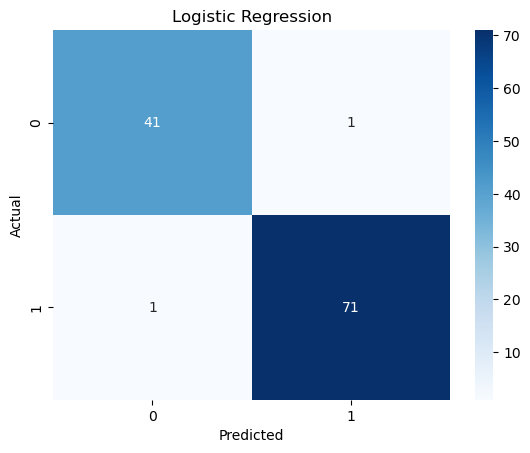

In [29]:
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The classification report shows Precision, Recall, F1-score, and Accuracy for each class.
The best model achieved high precision and recall, indicating that it correctly classified most malignant and benign cases with very few misclassifications.

In [31]:
#predit a new data

new_data = [[14.5, 20.1, 94.0, 650.0, 0.10,
             0.12, 0.08, 0.05, 0.18, 0.06,
             0.40, 1.20, 2.80, 40.0, 0.006,
             0.020, 0.025, 0.010, 0.018, 0.003,
             16.0, 25.0, 105.0, 800.0, 0.14,
             0.25, 0.30, 0.12, 0.28, 0.08]]

new_data_scaled = scaler.transform(new_data)

prediction = lr.predict(new_data_scaled)

print("Predicted Class:", prediction[0])

if prediction[0] == 0:
    print("Prediction: Malignant Cancer")
else:
    print("Prediction: Benign Cancer")

Predicted Class: 0
Prediction: Malignant Cancer


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [32]:
sample = X_test[0].reshape(1, -1)

prediction = lr.predict(sample)

print(prediction)

[0]


In [33]:
new_data1 = [[11.8, 17.5, 75.0, 430.0, 0.09,
             0.06, 0.03, 0.02, 0.17, 0.06,
             0.25, 0.90, 1.60, 18.0, 0.005,
             0.012, 0.015, 0.007, 0.015, 0.002,
             13.2, 22.0, 84.0, 520.0, 0.12,
             0.14, 0.12, 0.06, 0.24, 0.07]]

new_data_scaled1 = scaler.transform(new_data1)

prediction = lr.predict(new_data_scaled1)

if prediction[0] == 0:
    print("Prediction: Malignant Cancer")
else:
    print("Prediction: Benign Cancer")

Prediction: Benign Cancer


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
